# Dataset Analysis

Structural analysis of Solomon-format datasets used in UAV routing experiments.
Covers spatial layout, time window structure, information distribution,
calibration effects, and instance characterization.

**Datasets:** 5 Solomon instances (C101/R101 at 50 nodes, C101/R101/RC101 at 100 nodes).

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from uav_routing.environment.data import data_to_dict, to_dataframe
from uav_routing.environment.graph import Graph
from uav_routing.environment.drone import Drone
from uav_routing.environment.calibration import calibrate, calibration_info, CalibrationResult
from uav_routing.environment.data_analysis import (
    analyse_datasets,
    plot_distance_vs_tw_open,
    plot_binned_tw_open,
    plot_temporal_reachability,
    plot_tw_timeline,
    plot_tw_width_histogram,
    plot_tightness_ratio,
)

# Dataset paths
DATA_DIR = "../datasets/data"
paths = {
    "C101 (50)":  os.path.join(DATA_DIR, "50_c101.txt"),
    "R101 (50)":  os.path.join(DATA_DIR, "50_r101.txt"),
    "RC101 (100)": os.path.join(DATA_DIR, "rc101.txt"),
    "R101 (100)": os.path.join(DATA_DIR, "r101.txt"),
    "C101 (100)": os.path.join(DATA_DIR, "c101.txt"),
}

path_list = list(paths.values())
SORTIE_TIME = 3.0

---
## 1. Instance Summary Table

Basic statistics for each dataset: nodes, depot position, campaign time,
spatial spread, time window characteristics.

**Purpose:** Characterize each instance before running experiments.
- C-type (clustered): tighter TW grouping, shorter inter-customer distances.
- R-type (random): uniform spatial spread, wider TW variation.
- RC-type (mixed): combination of clustered and random.
- Tightness ratio = mean TW width / campaign time — lower means more constrained scheduling, which directly affects solver difficulty.

In [2]:
summary_rows = []
for name, path in paths.items():
    nodes, depot = data_to_dict(path)
    depot = int(depot)
    customers = {k: v for k, v in nodes.items() if k != depot}
    
    # Spatial
    positions = np.array([v['position'] for v in customers.values()])
    depot_pos = np.array(nodes[depot]['position'])
    dists = np.sqrt(np.sum((positions - depot_pos)**2, axis=1))
    
    # Time windows
    tw_opens = np.array([v['time_window'][0] for v in customers.values()])
    tw_closes = np.array([v['time_window'][1] for v in customers.values()])
    tw_widths = tw_closes - tw_opens
    campaign = nodes[depot]['time_window'][1]
    
    # Information
    infos = np.array([v['info_at_lowest'] for v in customers.values()])
    
    summary_rows.append({
        "Instance": name,
        "n (incl depot)": len(nodes),
        "Depot position": f"({depot_pos[0]:.0f}, {depot_pos[1]:.0f})",
        "Campaign time": campaign,
        "Dist to depot: mean": round(dists.mean(), 1),
        "Dist to depot: max": round(dists.max(), 1),
        "TW width: mean": round(tw_widths.mean(), 1),
        "TW width: std": round(tw_widths.std(), 1),
        "TW width: min": round(tw_widths.min(), 1),
        "Tightness ratio": round(tw_widths.mean() / campaign, 4),
        "Info at lowest: mean": round(infos.mean(), 1),
        "Info at lowest: std": round(infos.std(), 1),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Instance,n (incl depot),Depot position,Campaign time,Dist to depot: mean,Dist to depot: max,TW width: mean,TW width: std,TW width: min,Tightness ratio,Info at lowest: mean,Info at lowest: std
0,C101 (50),51,"(40, 50)",1236.0,24.1,41.2,60.1,10.9,37.0,0.0487,17.2,9.4
1,R101 (50),51,"(35, 35)",230.0,26.2,43.9,10.0,0.0,10.0,0.0435,14.4,8.3
2,RC101 (100),101,"(40, 50)",240.0,33.1,58.5,30.0,0.0,30.0,0.1250,17.2,9.4
3,R101 (100),101,"(35, 35)",230.0,24.9,49.9,10.0,0.0,10.0,0.0435,14.6,8.8
4,C101 (100),101,"(40, 50)",1236.0,28.9,58.5,60.8,10.5,37.0,0.0492,18.1,10.4


---
## 2. Spatial Layout

Node positions with depot highlighted, colored by base information value.

**Purpose:** Visually confirm instance geometry (clustered vs random vs mixed) and check whether high-information nodes are spatially correlated with distance from depot.

/var/folders/jq/95qm3sf916j86sv1p7xgh52c0000gn/T/ipykernel_1720/2289582406.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 0.95])


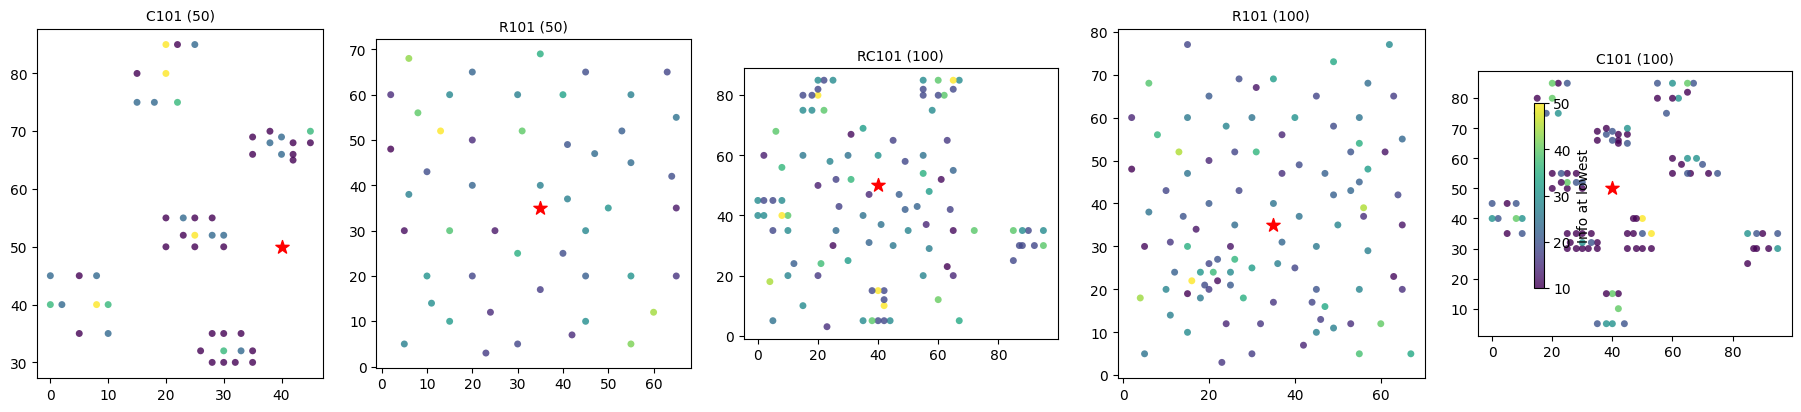

In [6]:
fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4), squeeze=False)

for ax, (name, path) in zip(axes[0], paths.items()):
    nodes, depot = data_to_dict(path)
    depot = int(depot)
    
    cust_pos = np.array([v['position'] for k, v in nodes.items() if k != depot])
    depot_pos = np.array(nodes[depot]['position'])
    infos = np.array([v['info_at_lowest'] for k, v in nodes.items() if k != depot])
    
    sc = ax.scatter(cust_pos[:, 0], cust_pos[:, 1], c=infos, cmap='viridis',
                    s=25, alpha=0.8, edgecolors='none')
    ax.scatter(*depot_pos, c='red', s=100, marker='*', zorder=5, label='Depot')
    ax.set_title(name, fontsize=10)
    ax.set_aspect('equal')
   

fig.colorbar(sc, ax=axes[0].tolist(), shrink=0.6, label='Info at lowest')
fig.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()

---
## 3. Distance vs Time Window Analysis

**Purpose:** Test whether farther nodes open later (positive Spearman ρ suggests Solomon's TWs encode a radial routing progression from depot). This affects calibration: if TW openings correlate with distance, the spatial scale must preserve this relationship.

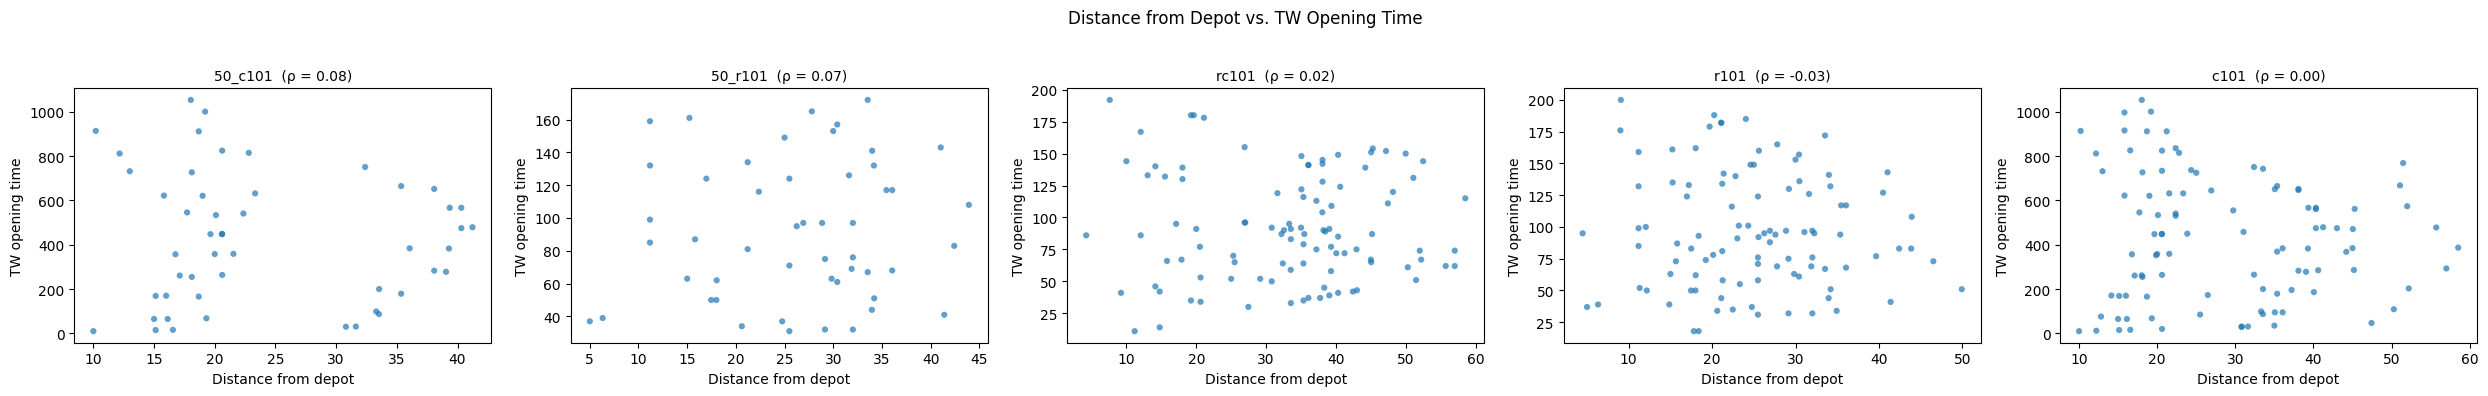

In [4]:
fig1 = plot_distance_vs_tw_open(path_list)
plt.show()

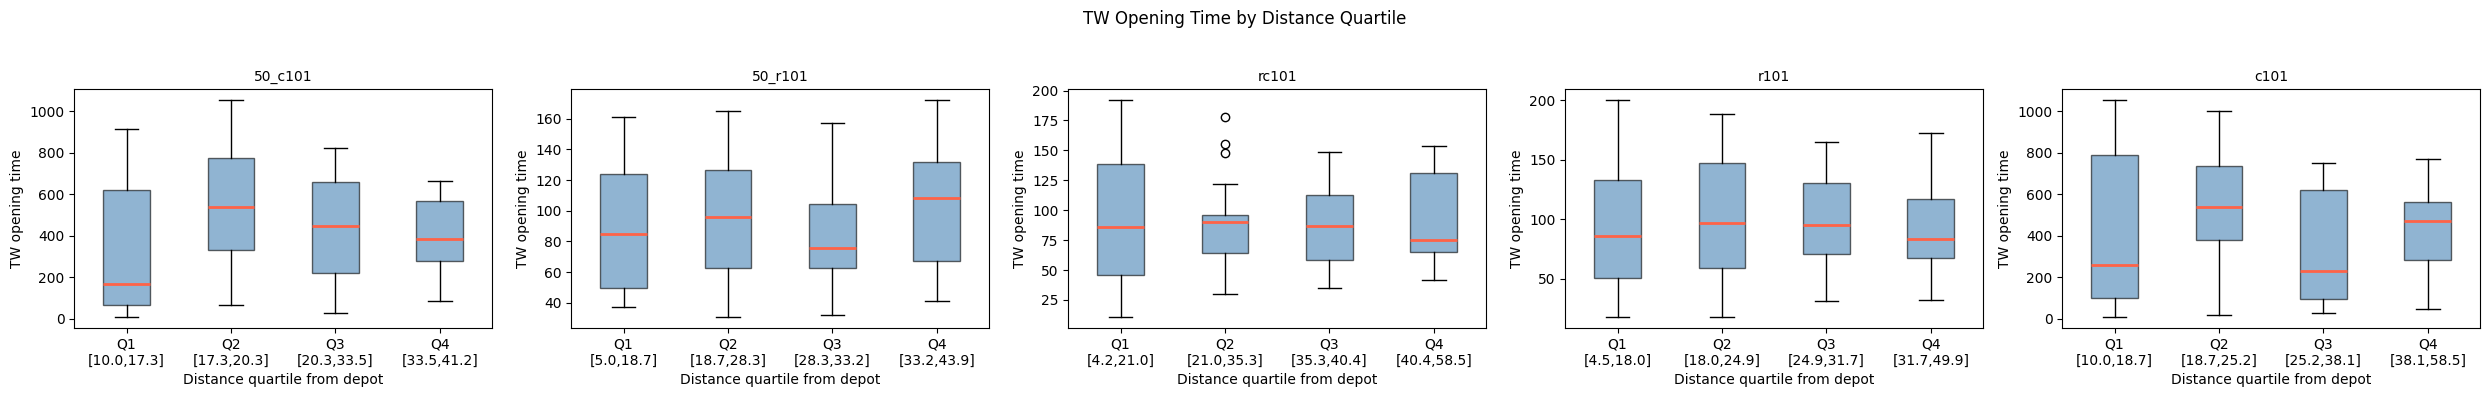

In [5]:
fig2 = plot_binned_tw_open(path_list)
plt.show()

---
## 4. Time Window Structure

**Purpose:** Visualize scheduling density (timeline), flexibility (width distribution), and constraint severity (tightness ratio). Dense overlapping TWs create scheduling conflicts; narrow widths limit speed optimization freedom. Tightness ratio is a single metric predicting solver difficulty.

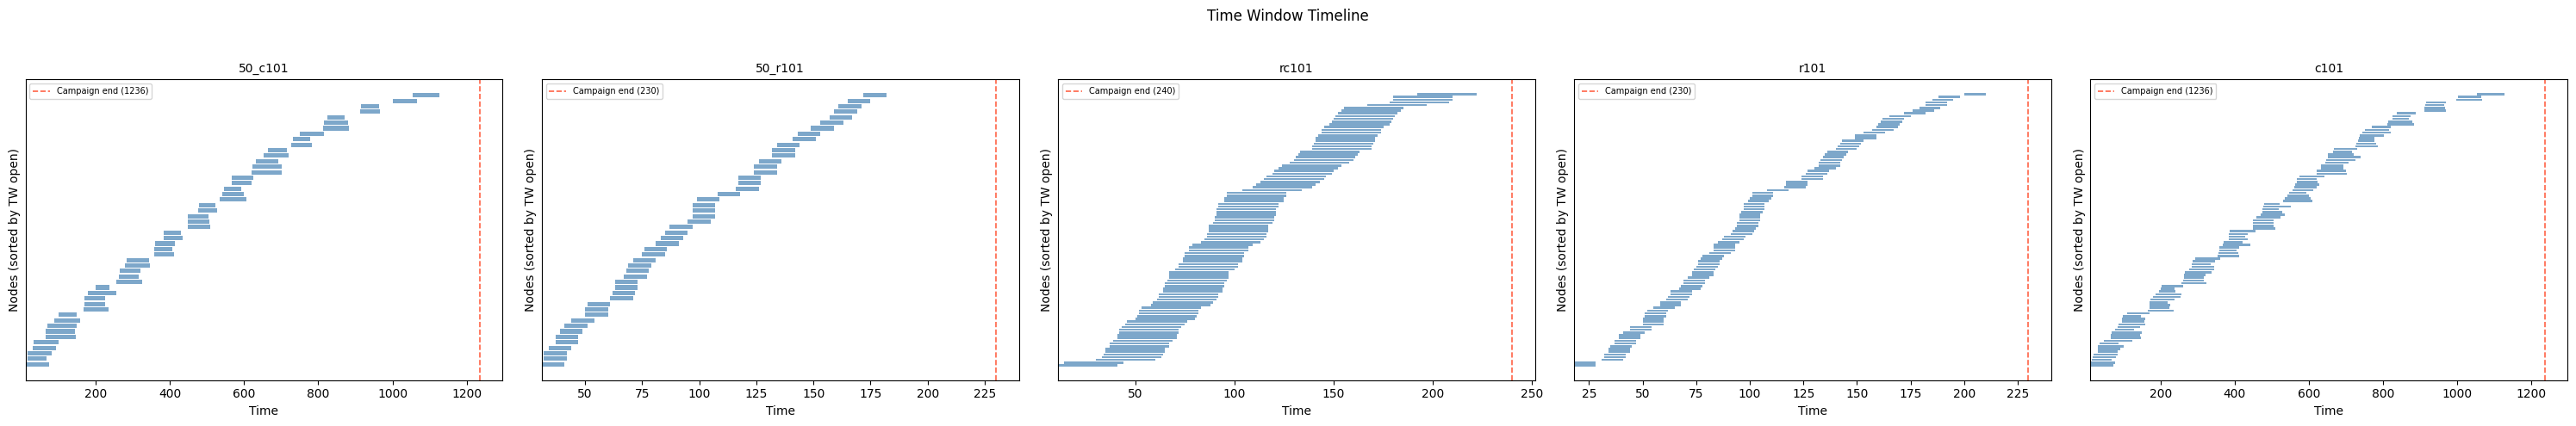

In [6]:
fig3 = plot_tw_timeline(path_list)
plt.show()

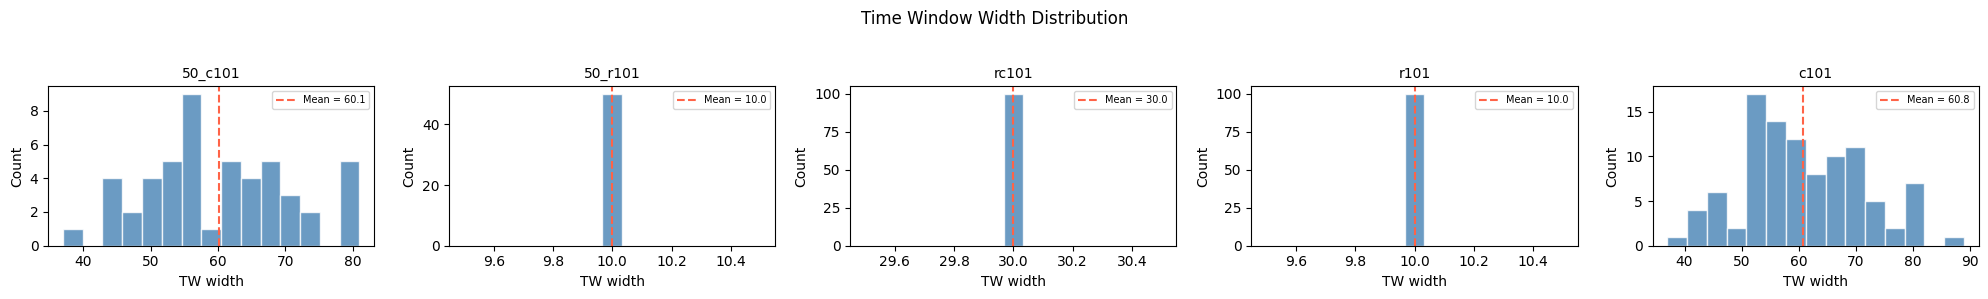

In [7]:
fig4 = plot_tw_width_histogram(path_list)
plt.show()

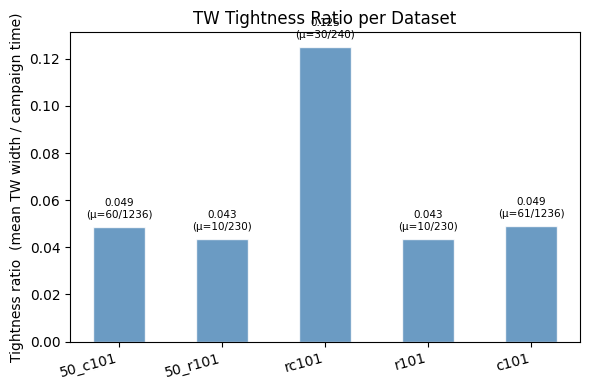

In [8]:
fig5 = plot_tightness_ratio(path_list)
plt.show()

---
## 5. Temporal Reachability

**Purpose:** Identify nodes that are temporally unreachable under Solomon's d=t assumption. Points above the diagonal mean the drone arrives before the TW opens (must wait). After calibration, reachability changes because spatial and time scales are decoupled.

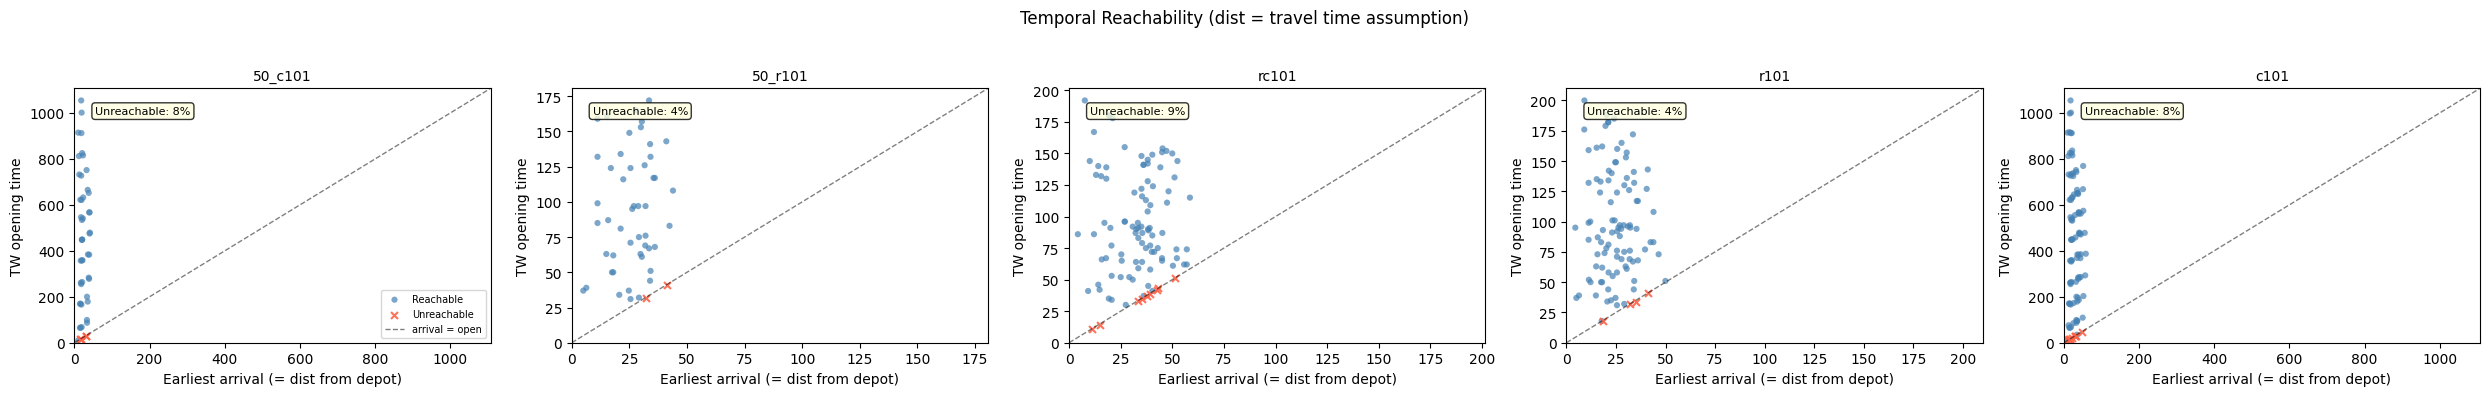

In [9]:
fig6 = plot_temporal_reachability(path_list)
plt.show()

---
## 6. Information Value Distribution

**Purpose:** Understand the information landscape. If info is uncorrelated with distance (ρ ≈ 0), the drone faces a genuine trade-off between nearby low-info nodes vs far high-info nodes. The distribution shape affects which initial tour heuristics work best.

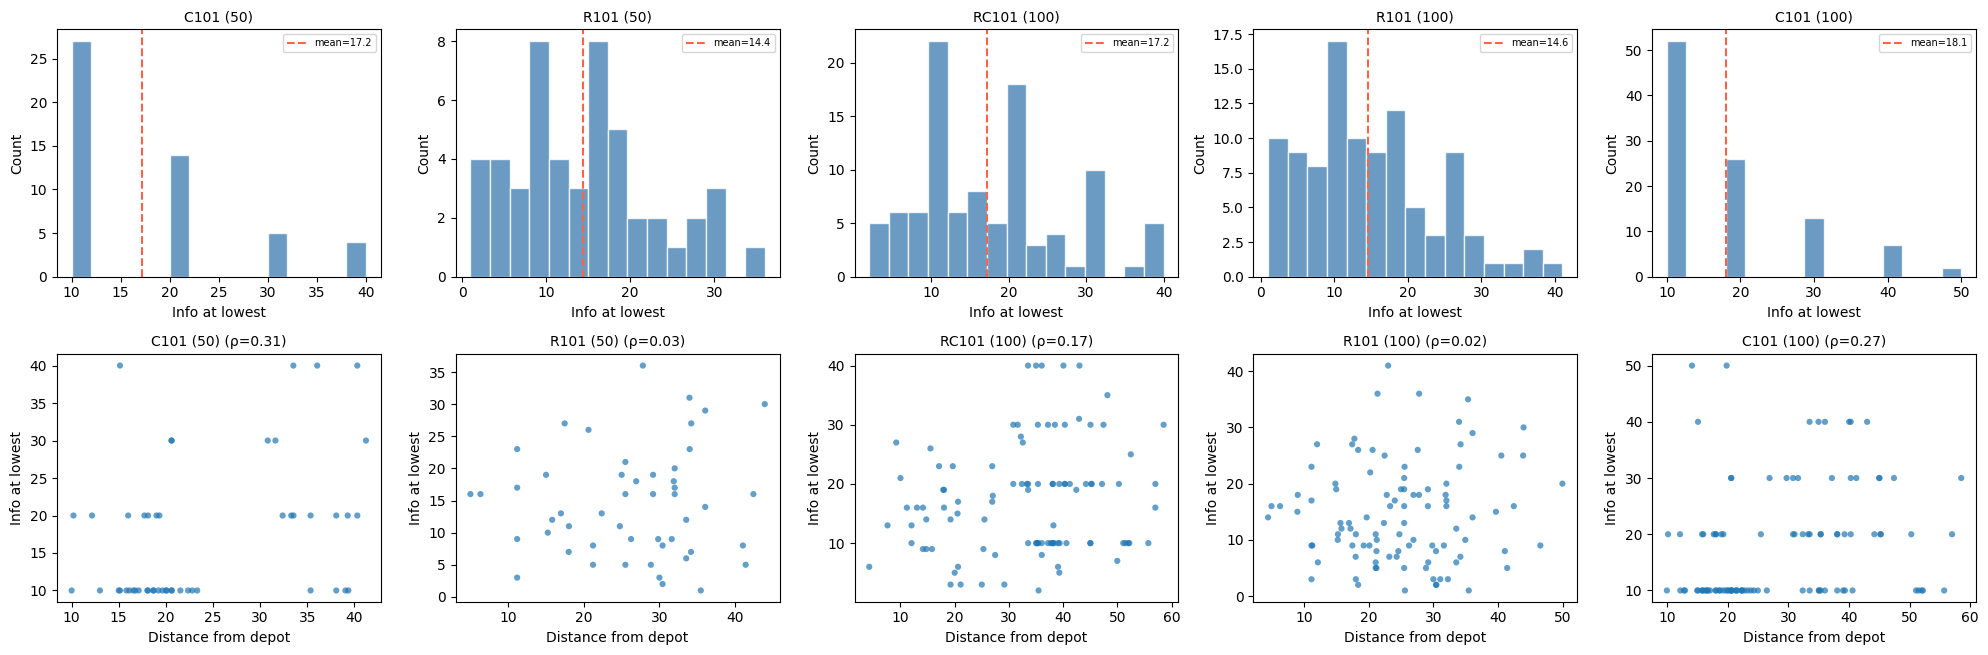

In [7]:
fig, axes = plt.subplots(2, len(paths), figsize=(4 * len(paths), 7), squeeze=False)

for col, (name, path) in enumerate(paths.items()):
    nodes, depot = data_to_dict(path)
    depot = int(depot)
    infos = np.array([v['info_at_lowest'] for k, v in nodes.items() if k != depot])
    
    # Row 1: Info histogram
    ax1 = axes[0, col]
    ax1.hist(infos, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
    ax1.axvline(infos.mean(), color='tomato', linestyle='--', label=f'mean={infos.mean():.1f}')
    ax1.set_title(name, fontsize=10)
    ax1.set_xlabel('Info at lowest')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=7)
    
    # Row 2: Info vs distance from depot
    depot_pos = np.array(nodes[depot]['position'])
    cust = {k: v for k, v in nodes.items() if k != depot}
    dists = np.array([math.sqrt((v['position'][0]-depot_pos[0])**2 + 
                                (v['position'][1]-depot_pos[1])**2) for v in cust.values()])
    ax2 = axes[1, col]
    rho, _ = spearmanr(dists, infos)
    ax2.scatter(dists, infos, s=20, alpha=0.7, edgecolors='none')
    ax2.set_title(f'{name} (ρ={rho:.2f})', fontsize=10)
    ax2.set_xlabel('Distance from depot')
    ax2.set_ylabel('Info at lowest')

axes[0, 0].set_ylabel('Count')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 7. Slope Regime Visualization

**Purpose:** Show what the solver "sees" under each regime. Random slopes create per-node early/late trade-offs; positive slopes uniformly reward late arrival; zero slopes make timing irrelevant. This explains the solver behavior differences in the exact solver experiments.

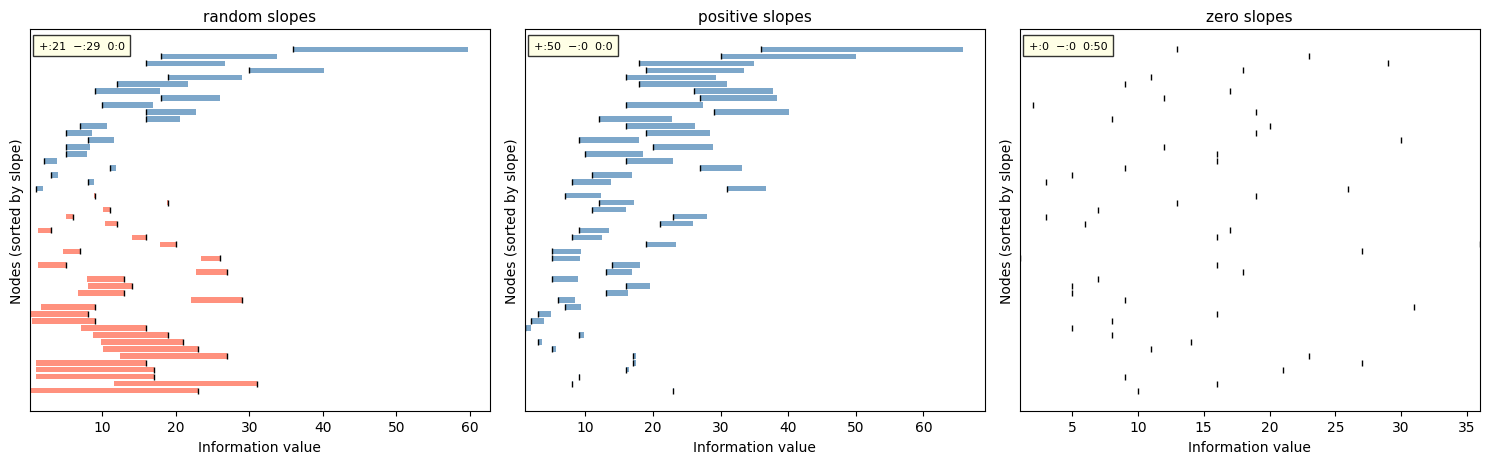

In [8]:
test_path = paths["R101 (50)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, slope in zip(axes, ['random', 'positive', 'zero']):
    graph = Graph(path=test_path, slope=slope, seed=1)
    depot = graph.graph['base']
    customers = [n for n in graph.nodes if n != depot]
    
    slopes = np.array([graph.nodes[n]['info_slope'] for n in customers])
    infos = np.array([graph.nodes[n]['info_at_lowest'] for n in customers])
    tw_widths = np.array([graph.nodes[n]['time_window'][1] - graph.nodes[n]['time_window'][0]
                          for n in customers])
    
    info_at_open = infos
    info_at_close = infos + slopes * tw_widths
    
    order = np.argsort(slopes)
    y = np.arange(len(customers))
    
    for i, idx in enumerate(order):
        lo = min(info_at_open[idx], info_at_close[idx])
        hi = max(info_at_open[idx], info_at_close[idx])
        color = 'steelblue' if slopes[idx] >= 0 else 'tomato'
        ax.barh(i, hi - lo, left=lo, height=0.8, color=color, alpha=0.7)
        ax.plot(info_at_open[idx], i, 'k|', markersize=4)
    
    ax.set_title(f'{slope} slopes', fontsize=11)
    ax.set_xlabel('Information value')
    ax.set_ylabel('Nodes (sorted by slope)')
    ax.set_yticks([])
    
    n_pos = (slopes > 0).sum()
    n_neg = (slopes < 0).sum()
    n_zero = (slopes == 0).sum()
    ax.text(0.02, 0.97, f'+:{n_pos}  −:{n_neg}  0:{n_zero}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(facecolor='lightyellow', alpha=0.8))

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 8. Calibration Effects

**Purpose:** Verify that campaign-time calibration produces consistent physical units. Scaled campaign should equal T_sortie = 3h = 10800s for all instances. E_max = P(v_opt) · T_sortie should be identical across instances. The TW timeline comparison confirms calibration preserves relative structure while mapping to real-world units.

In [12]:
calib_rows = []
for name, path in paths.items():
    graph = Graph(path=path, seed=1)
    uav = Drone(base=graph.graph['base'])
    depot = graph.graph['base']
    
    calib = calibrate(
        graph=graph,
        tour_length=len(graph.nodes) // 2,
        drone=uav,
        drone_sortie_time=SORTIE_TIME,
        calibration_method="campaign",
    )
    
    # Raw Solomon stats
    raw_campaign = graph.nodes[depot]['time_window'][1]
    raw_dists = [graph.edges[e]['distance'] for e in graph.edges]
    
    # Calibrated stats
    cal_campaign = calib.graph.nodes[depot]['time_window'][1]
    cal_dists = [calib.graph.edges[e]['distance'] for e in calib.graph.edges]
    
    calib_rows.append({
        "Instance": name,
        "Solomon campaign": raw_campaign,
        "Scaled campaign (s)": round(cal_campaign, 1),
        "Scaled campaign (h)": round(cal_campaign / 3600, 2),
        "Spatial scale (m/unit)": round(calib.spatial_scale, 2),
        "Time scale (s/unit)": round(calib.time_scale, 4),
        "Solomon mean dist": round(np.mean(raw_dists), 1),
        "Scaled mean dist (m)": round(np.mean(cal_dists), 1),
        "E_max (J)": f"{calib.scaled_max_energy:.2e}",
        "Ref tour dist (Sol)": round(calib.tour_dist_solomon, 1),
        "Ref tour dist (m)": round(calib.tour_distance_drone, 1),
    })

df_calib = pd.DataFrame(calib_rows)
df_calib

,Instance,Solomon campaign,Scaled campaign (s),Scaled campaign (h),Spatial scale (m/unit),Time scale (s/unit),Solomon mean dist,Scaled mean dist (m),E_max (J),Ref tour dist (Sol),Ref tour dist (m)
0,C101 (50),1236.0,10800.0,3.0,387.17,8.7379,26.5,10246.1,1.70e+08,135.5,52472.6
1,R101 (50),230.0,10800.0,3.0,2080.64,46.9565,35.7,74376.3,1.70e+08,223.3,464563.1
2,RC101 (100),240.0,10800.0,3.0,1993.95,45.0000,44.7,89199.7,1.70e+08,384.6,766876.8
3,R101 (100),230.0,10800.0,3.0,2080.64,46.9565,34.0,70641.3,1.70e+08,365.2,759855.9
4,C101 (100),1236.0,10800.0,3.0,387.17,8.7379,39.5,15281.9,1.70e+08,243.8,94399.6


### 8b. Before vs After Calibration: TW Timeline

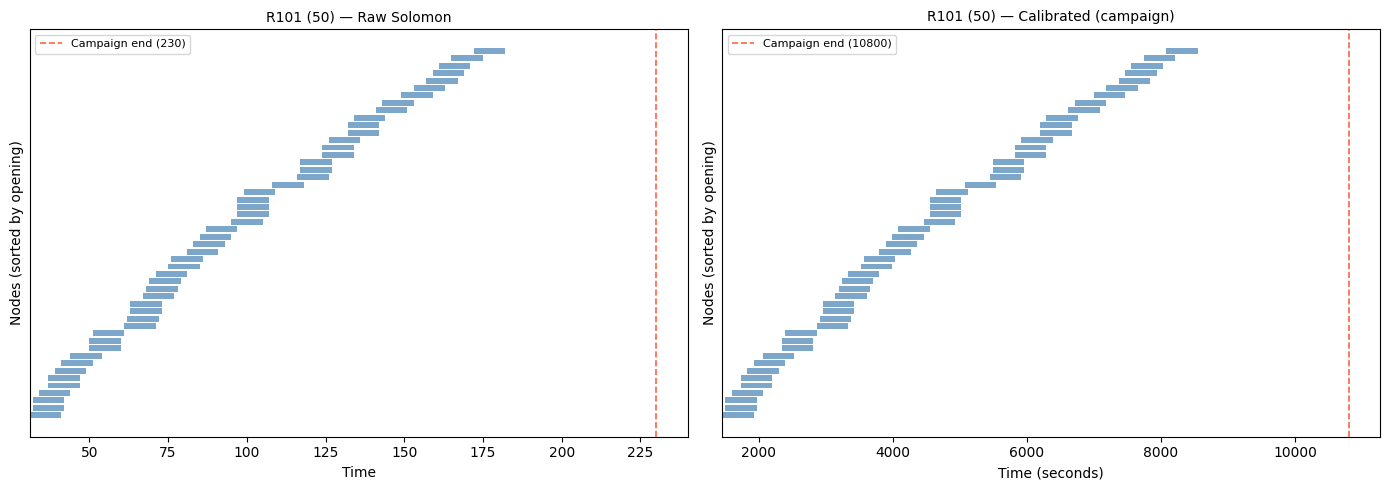

In [13]:
# Show TW timeline before and after calibration for one instance
test_name = "R101 (50)"
test_path = paths[test_name]

graph = Graph(path=test_path, seed=1)
uav = Drone(base=graph.graph['base'])
calib = calibrate(graph=graph, tour_length=len(graph.nodes)//2,
                  drone=uav, drone_sortie_time=SORTIE_TIME, calibration_method="campaign")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
depot = graph.graph['base']

for ax, (g, title) in zip(axes, [(graph, 'Raw Solomon'), (calib.graph, 'Calibrated (campaign)')]):
    customers = [n for n in g.nodes if n != depot]
    opens = np.array([g.nodes[n]['time_window'][0] for n in customers])
    closes = np.array([g.nodes[n]['time_window'][1] for n in customers])
    campaign = g.nodes[depot]['time_window'][1]
    
    order = np.argsort(opens)
    y = np.arange(len(customers))
    ax.barh(y, closes[order] - opens[order], left=opens[order],
            height=0.8, color='steelblue', alpha=0.7)
    ax.axvline(campaign, color='tomato', linestyle='--', linewidth=1.2,
               label=f'Campaign end ({campaign:.0f})')
    ax.set_title(f'{test_name} — {title}', fontsize=10)
    ax.set_xlabel('Time' if title == 'Raw Solomon' else 'Time (seconds)')
    ax.set_ylabel('Nodes (sorted by opening)')
    ax.set_yticks([])
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 9. Energy Landscape

**Purpose:** Identify "easy wins" (high info, low energy cost = bright color) vs "expensive targets" (low info, high energy = dark). The spread of this scatter determines how much the energy budget affects tour composition and which nodes the R6 heuristic should prioritize.

/var/folders/jq/95qm3sf916j86sv1p7xgh52c0000gn/T/ipykernel_93326/1401784850.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 0.95])


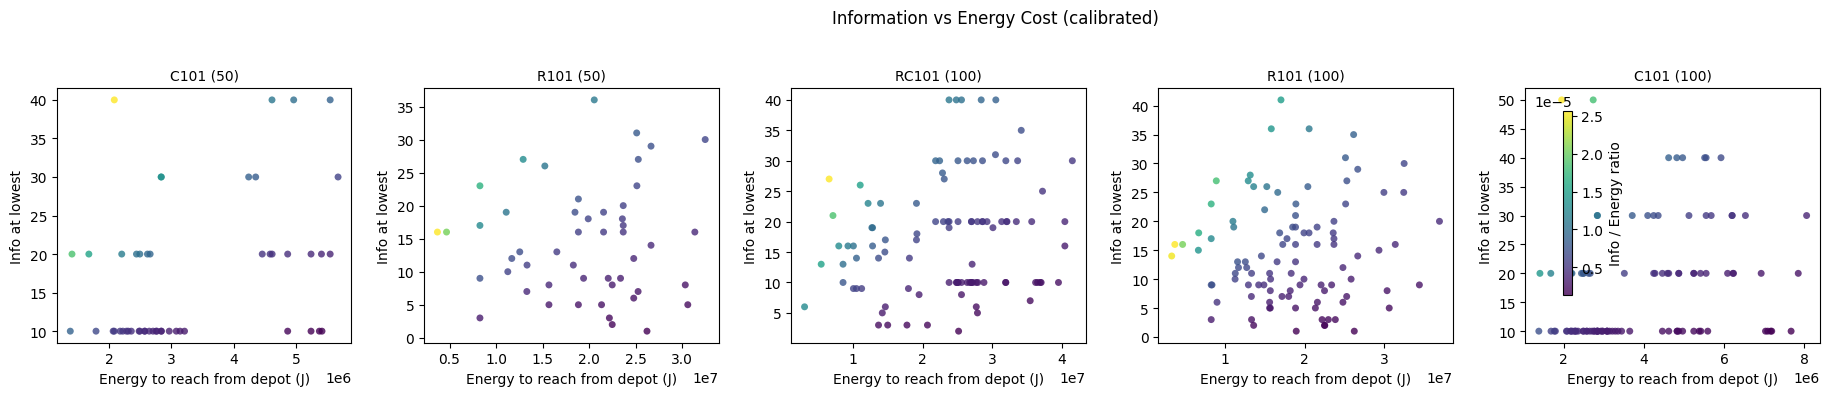

In [14]:
fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4), squeeze=False)

for ax, (name, path) in zip(axes[0], paths.items()):
    graph = Graph(path=path, seed=1)
    uav = Drone(base=graph.graph['base'])
    depot = graph.graph['base']
    calib = calibrate(graph=graph, tour_length=len(graph.nodes)//2,
                      drone=uav, drone_sortie_time=SORTIE_TIME, calibration_method="campaign")
    
    customers = [n for n in calib.graph.nodes if n != depot]
    depot_dists = np.array([calib.graph.edges[(depot, n)]['distance'] for n in customers])
    depot_energy = np.array([uav.energy_function(uav.optimum_speed, d) for d in depot_dists])
    infos = np.array([calib.graph.nodes[n]['info_at_lowest'] for n in customers])
    
    ratio = infos / depot_energy
    
    sc = ax.scatter(depot_energy, infos, c=ratio, cmap='viridis',
                    s=25, alpha=0.8, edgecolors='none')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Energy to reach from depot (J)')
    ax.set_ylabel('Info at lowest')

fig.suptitle('Information vs Energy Cost (calibrated)', fontsize=12)
fig.colorbar(sc, ax=axes[0].tolist(), shrink=0.6, label='Info / Energy ratio')
fig.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()

---
## 10. Instance Difficulty Indicators

**Purpose:** Predict and explain solver performance differences. Affordable nodes (%) = how many nodes are reachable within E_max; TW overlap (%) = scheduling conflict density; Spatial CV = spatial heterogeneity. Cross-reference with exact solver results: high affordable % and high TW overlap should correlate with larger MIP gaps.

In [15]:
diff_rows = []
for name, path in paths.items():
    graph = Graph(path=path, seed=1)
    uav = Drone(base=graph.graph['base'])
    depot = graph.graph['base']
    calib = calibrate(graph=graph, tour_length=len(graph.nodes)//2,
                      drone=uav, drone_sortie_time=SORTIE_TIME, calibration_method="campaign")
    
    customers = [n for n in calib.graph.nodes if n != depot]
    n_cust = len(customers)
    
    # Calibrated distances and TW
    depot_dists = [calib.graph.edges[(depot, n)]['distance'] for n in customers]
    tw_widths = [calib.graph.nodes[n]['time_window'][1] - calib.graph.nodes[n]['time_window'][0]
                 for n in customers]
    
    # Energy to visit each node (round trip at v_opt)
    round_trip_energy = [uav.energy_function(uav.optimum_speed, 2*d) for d in depot_dists]
    affordable = sum(1 for e in round_trip_energy if e <= calib.scaled_max_energy)
    
    # TW overlap: fraction of node pairs with overlapping time windows
    tw_opens = [calib.graph.nodes[n]['time_window'][0] for n in customers]
    tw_closes = [calib.graph.nodes[n]['time_window'][1] for n in customers]
    overlap_count = 0
    total_pairs = 0
    for i in range(n_cust):
        for j in range(i+1, n_cust):
            total_pairs += 1
            if tw_opens[i] < tw_closes[j] and tw_opens[j] < tw_closes[i]:
                overlap_count += 1
    
    diff_rows.append({
        "Instance": name,
        "n": n_cust + 1,
        "Affordable nodes (%)": round(affordable / n_cust * 100, 1),
        "TW overlap (%)": round(overlap_count / total_pairs * 100, 1),
        "Mean TW width (s)": round(np.mean(tw_widths), 0),
        "Tightness": round(np.mean(tw_widths) / calib.graph.nodes[depot]['time_window'][1], 4),
        "Spatial CV": round(np.std(depot_dists) / np.mean(depot_dists), 3),
    })

df_diff = pd.DataFrame(diff_rows)
df_diff

,Instance,n,Affordable nodes (%),TW overlap (%),Mean TW width (s),Tightness,Spatial CV
0,C101 (50),51,100.0,8.9,525.0,0.0487,0.388
1,R101 (50),51,100.0,11.8,470.0,0.0435,0.358
2,RC101 (100),101,100.0,37.4,1350.0,0.1250,0.385
3,R101 (100),101,100.0,11.7,470.0,0.0435,0.380
4,C101 (100),101,100.0,10.1,531.0,0.0492,0.424
